# Objective

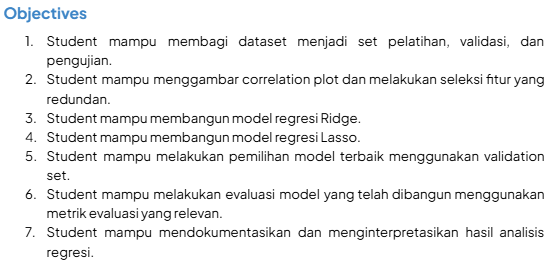

## Scoring Indicators

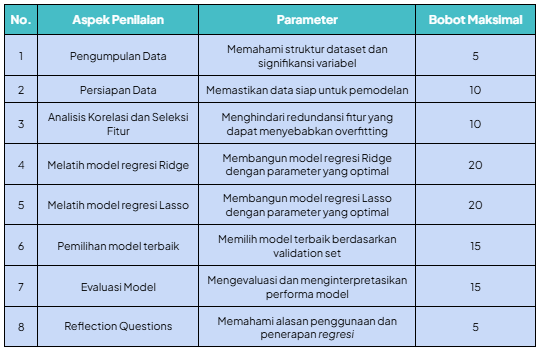

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
# Feature Engineering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Model
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
# Cross-Validation
from sklearn.model_selection import train_test_split
# Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error
# Model Diagnostics
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Read Dataset

In [ ]:
df = pd.read_csv('/content/boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


# Data Understanding

| Column   | Description |
|:--------:|:------------:|
| crim     | Per capita crime rate by town |
| zn       | Proportion of residential land zoned for lots over 25,000 sq.ft |
| indus    | Proportion of non-retail business acres per town |
| chas     | 1 if the tract bounds the Charles River, 0 otherwise |
| nox      | Nitric oxides concentration parts per 10 million |
| rm       | Average number of rooms per dwelling |
| age      | Proportion of owner-occupied units built prior to 1940 |
| dis      | Weighted distances to five Boston employment centers |
| rad      | Index of accessibility to radial highways |
| tax      | Full-value property tax rate per 10,000 dollar |  
| ptratio  | Pupil teacher ratio by town |
| black    | 1000(Bk − 0.63)², where Bk is the proportion of Black population |
| lstat    | Percentage of lower-status population |
| medv     | Median value of owner-occupied homes in $1000s |


# Data Preprocessing

## Missing Values

In [ ]:
df.isna().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


No Missing Values

## Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

- Dataset already clean, no duplicates, no Missing Values

## Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


The dataset was checked for missing values and duplicates, and no issues were found. An 80:20 train-test split was applied to separate the data for model training and evaluation. Since Ridge and Lasso are sensitive to the scale of the features, StandardScaler was applied to the training data and then used to transform the test data. This ensures consistency in feature scaling and prepares the dataset properly for regression modeling.

# Train Test Split

In [ ]:
# Define Target and Features
# Target
y = df['medv']
# Features
X = df.drop('medv', axis=1).copy()

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

# EDA

Build dataframe that contains both feature and target for analysis

In [ ]:
df_train = pd.concat([X_train, y_train], axis = 1)
df_train.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,349.48,24.91,12.0
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,395.62,8.47,19.9
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,362.25,7.83,19.4
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,2.52,23.29,13.4
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,390.95,11.28,18.2


In [ ]:
df_train.shape

(404, 14)

## Correlation Heatmap

Correlation between variables, both features and target

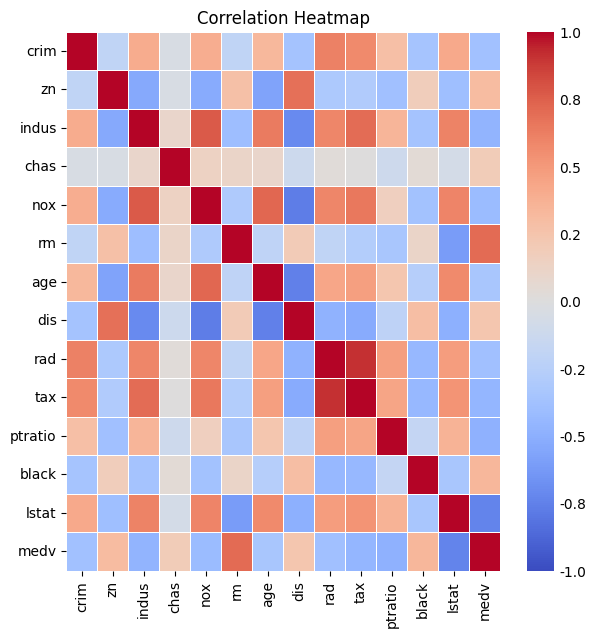

In [ ]:
corr_data = pd.concat([df_train.select_dtypes(include = ['int', 'float'])])
corr_data = corr_data.corr()
# Plot heatmap
plt.figure(figsize=(7, 7))
ax = sns.heatmap(corr_data, annot=False, cmap='coolwarm', fmt=".1f", vmin = -1, vmax= 1, linewidths=0.5, cbar_kws={'format': '%.1f'} )
ax.collections[0].colorbar.ax.tick_params(size=0)
plt.title("Correlation Heatmap")
plt.show()

The Boston Housing dataset contains 13 predictive features that describe socioeconomic, environmental, and structural characteristics of different neighborhoods, with `medv` as the target variable. From the correlation heatmap, rm shows a strong positive relationship with housing prices, while `lstat` and `crim` have strong negative correlations, indicating that areas with larger homes tend to be more valuable, whereas higher crime and lower socioeconomic status reduce property value. Some variables such as `rad` and `tax` are highly correlated with each other, suggesting multicollinearity, which is important to consider when choosing a regression model.

# Feature Engineering

Perform Standard Scaler to train dataset

In [ ]:
# Standard Scaler
scaler = StandardScaler()

In [ ]:
# Fit and Transform X train
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
# Fit and Transform X Test
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Convert scaled X train to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

# Convert scaled X test to DataFrame
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# Reset Index
X_train_scaled = X_train_scaled.reset_index(drop=True)
X_test_scaled = X_test_scaled.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

df_train_scaled = pd.concat([X_train_scaled, y_train_reset], axis = 1)
df_train_scaled.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1.287702,-0.500320,1.033237,-0.278089,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505,12.0
1,-0.336384,-0.500320,-0.413160,-0.278089,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474,19.9
2,-0.403253,1.013271,-0.715218,-0.278089,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595,19.4
3,0.388230,-0.500320,1.033237,-0.278089,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387,13.4
4,-0.325282,-0.500320,-0.413160,-0.278089,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787,18.2


# Model Fitting & Evaluation

In [ ]:
# Custom function to display model evaluation metrics
def evaluate_model(true, prediction, label):

  temp_result = pd.DataFrame({'Remark': label,
                              'R-square': [r2_score(true, prediction)*100],
                              'MAE' : [mean_absolute_error(true, prediction)],
                              'RMSE' : root_mean_squared_error(true, prediction),
                              'MAPE' : mean_absolute_percentage_error(true, prediction)
                              })
  return temp_result


# Customer function to display model coefficient
def get_model_coefficients(model, feature_names):

    coef_table = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_
    })

    coef_table['abs_value'] = np.abs(coef_table['Coefficient'])
    coef_table.sort_values('abs_value', ascending = False, inplace = True)

    plt.figure(figsize=(6, 9))
    ax = sns.barplot(x=coef_table['Coefficient'], y = coef_table['Feature'])

    for index, value in enumerate(coef_table['Coefficient']):
      ax.text(value, index, f'{value:.2f}', color='black', ha="left", va="center")
    plt.show()

In [ ]:
model_ols_scaled = LinearRegression()

model_ols_scaled.fit(X_train_scaled, y_train)
# Prediction
pred_train_ols = model_ols_scaled.predict(X_train_scaled)
pred_test_ols = model_ols_scaled.predict(X_test_scaled)
# -----Evaluate-----
results = pd.concat([
    evaluate_model(y_train, pred_train_ols, "Train"),
    evaluate_model(y_test, pred_test_ols, "Test")
]).reset_index(drop=True)

results

,Remark,R-square,MAE,RMSE,MAPE
0,Train,75.088564,3.314772,4.652033,0.165749
1,Test,66.875949,3.189092,4.928602,0.168664


In [ ]:
model_ols_scaled.coef_

array([-1.00213533,  0.69626862,  0.27806485,  0.7187384 , -2.0223194 ,
        3.14523956, -0.17604788, -3.0819076 ,  2.25140666, -1.76701378,
       -2.03775151,  1.12956831, -3.61165842])

## Visualize The Model Coefficients

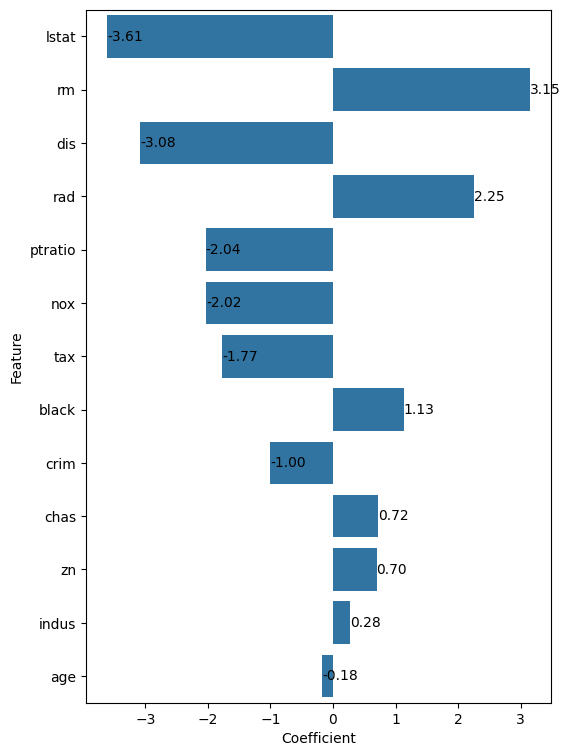

In [ ]:
model_ols = LinearRegression()
model_ols.fit(X_train_scaled, y_train_reset)
get_model_coefficients(model_ols, X_train_scaled.columns)

## Multicolinearity

In [ ]:
# Add constant
X_const = sm.add_constant(X_train_scaled)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

vif_data = vif_data[ vif_data['feature'] != 'const']
vif_data = vif_data[ vif_data['VIF'] > 5]

vif_data.sort_values('VIF', ascending = False)

,feature,VIF
10,tax,8.943301
9,rad,7.658316


Variance Inflation Factor (VIF) analysis shows that two features, tax (VIF = 8.49) and rad (VIF = 7.66), have moderately high VIF values. A VIF between 5 and 10 indicates moderate multicollinearity, meaning these features are highly correlated with other predictors in the dataset. This does not affect prediction performance, but it can make OLS coefficients unstable and less reliable for interpretation

Although tax and rad show moderately high VIF values, I decided not to drop these features because Ridge and Lasso are designed to handle multicollinearity through coefficient shrinkage, allowing the model to remain stable without removing predictors.

# Ridge

Ridge & Lasso:
Model techniques used to reduce overfitting by adding a penalty.

Regularization:
A method to reduce overfitting.

The larger the lambda value, the more the effect or weight of each feature is reduced.

## Effect of Lambda on Model Coefficient

In [ ]:
alphas = [0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 25, 50, 75, 100, 200, 300, 500, 600, 750, 1000]

trial_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    trial_coefs.append(ridge.coef_)

trial_coefs = np.array(trial_coefs)

trial_coefs = pd.DataFrame(trial_coefs)
trial_coefs.columns = X_train.columns
trial_coefs['alpha'] = alphas

trial_coefs.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,alpha
0,-1.002135,0.696269,0.278065,0.718738,-2.022319,3.145240,-0.176048,-3.081908,2.251407,-1.767014,-2.037752,1.129568,-3.611658,0.0000
1,-1.002134,0.696267,0.278062,0.718739,-2.022316,3.145240,-0.176048,-3.081904,2.251399,-1.767006,-2.037751,1.129568,-3.611657,0.0001
2,-1.002125,0.696250,0.278038,0.718742,-2.022287,3.145246,-0.176049,-3.081870,2.251326,-1.766939,-2.037741,1.129566,-3.611646,0.0010
3,-1.002033,0.696078,0.277797,0.718777,-2.021999,3.145306,-0.176061,-3.081533,2.250597,-1.766269,-2.037651,1.129545,-3.611530,0.0100
4,-1.001625,0.695314,0.276727,0.718932,-2.020719,3.145571,-0.176112,-3.080037,2.247362,-1.763297,-2.037247,1.129449,-3.611017,0.0500


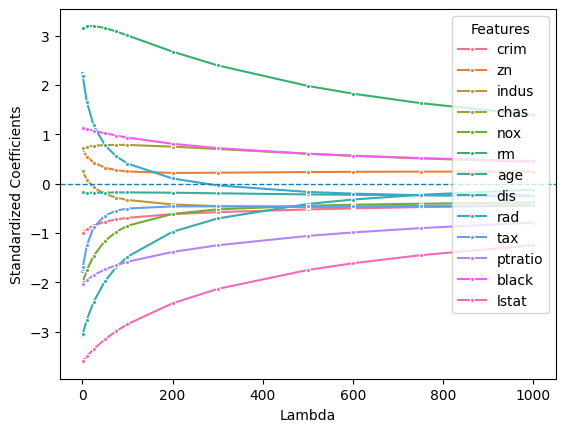

In [ ]:
selected_trial = trial_coefs[['alpha',
                              'crim','zn','indus','chas','nox','rm','age',
                              'dis','rad','tax','ptratio','black','lstat']].copy()

selected_trial = selected_trial.melt(
    id_vars=['alpha'],
    value_vars=[
        'crim','zn','indus','chas','nox','rm','age',
        'dis','rad','tax','ptratio','black','lstat'
    ],
    var_name='variable',
    value_name='value'
)

ax = sns.lineplot(
    data=selected_trial,
    x='alpha',
    y='value',
    hue='variable',
    marker="o",
    markersize=3
)

ax.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Lambda')
plt.ylabel('Standardized Coefficients')
plt.legend(title='Features')
plt.show()

## Find the Best Lambda

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 25, 50, 100, 200, 300, 500, 1000]

# initialize model
model_ridge = RidgeCV(alphas=alphas, cv=5)
model_ridge.fit(X_train_scaled, y_train)

print("\nBest Alpha")
print(model_ridge.alpha_)


Best Alpha
1.0


In [ ]:
pred_train_ridge = model_ridge.predict(X_train_scaled)
pred_ridge = model_ridge.predict(X_test_scaled)

pd.concat([evaluate_model(y_train, pred_train_ridge, "Train"),
           evaluate_model(y_test, pred_ridge, "Test")])

,Remark,R-square,MAE,RMSE,MAPE
0,Train,75.087024,3.308708,4.652177,0.165379
0,Test,66.846244,3.185724,4.930812,0.168547


Performance-wise, the Ridge model shows very similar results between the train and test sets, with only a small difference in RMSE (4.65 vs 4.93). This indicates that the model generalizes well and does not overfit. The test R-squared of approximately 66.8% is almost identical to OLS, suggesting that regularization does not significantly change predictive accuracy for this dataset. The regularization mainly stabilizes the coefficients without affecting performance, making Ridge a reliable alternative to OLS when multicollinearity is present.

Ridge regression was trained using RidgeCV, which automatically searched for the optimal alpha using cross-validation. Ridge penalizes large coefficients and shrinks them smoothly toward zero, helping stabilize the model when multicollinearity is present. From the coefficient path, we can see that the coefficients decrease gradually as lambda increases, but none of them become exactly zero. The selected alpha provided a model with stable coefficients and test performance comparable to OLS, with slightly lower variance and good generalization.

# Lasso

## Effect of Lambda on Lasso

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 25, 50, 75, 100, 200, 300, 500, 600, 750, 1000]

trial_coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=  5000)
    lasso.fit(X_train_scaled, y_train)
    trial_coefs.append(lasso.coef_)

trial_coefs = np.array(trial_coefs)

trial_coefs = pd.DataFrame(trial_coefs)
trial_coefs.columns = X_train_scaled.columns
trial_coefs['alpha'] = alphas

trial_coefs.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,alpha
0,-1.001857,0.695771,0.277154,0.718752,-2.021687,3.145303,-0.175820,-3.081205,2.249600,-1.765214,-2.037566,1.129449,-3.611634,0.0001
1,-0.999359,0.691300,0.268936,0.718880,-2.016029,3.145868,-0.173778,-3.074913,2.233347,-1.748999,-2.035900,1.128372,-3.611403,0.0010
2,-0.974393,0.646665,0.187143,0.720090,-1.959138,3.151434,-0.153203,-3.011678,2.071401,-1.587604,-2.019253,1.117646,-3.609323,0.0100
3,-0.862263,0.465774,0.000000,0.715886,-1.760624,3.192677,-0.067028,-2.701275,1.415492,-0.977813,-1.957721,1.075541,-3.608092,0.0500
4,-0.718365,0.259627,-0.000000,0.698221,-1.568142,3.271507,-0.000000,-2.284449,0.671938,-0.356654,-1.893335,1.031366,-3.609410,0.1000


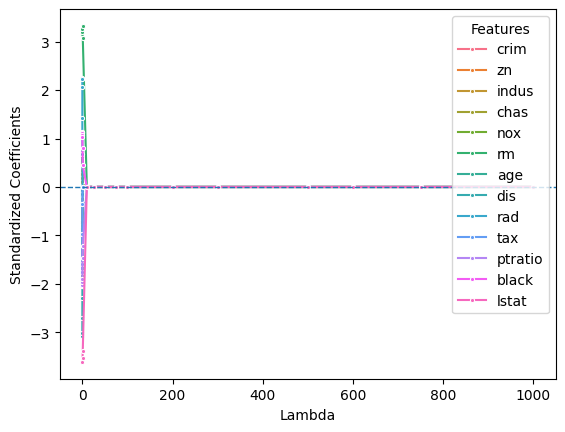

In [ ]:
selected_trial = trial_coefs[['alpha',
                              'crim','zn','indus','chas','nox','rm','age',
                              'dis','rad','tax','ptratio','black','lstat']].copy()

selected_trial = selected_trial.melt(
    id_vars=['alpha'],
    value_vars=[
        'crim','zn','indus','chas','nox','rm','age',
        'dis','rad','tax','ptratio','black','lstat'
    ],
    var_name='variable',
    value_name='value'
)

ax = sns.lineplot(
    data=selected_trial,
    x='alpha',
    y='value',
    hue='variable',
    marker="o",
    markersize=3
)

ax.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Lambda')
plt.ylabel('Standardized Coefficients')
plt.legend(title='Features')
plt.show()

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 25, 50, 100, 200, 300, 500, 1000]

# initialize model
model_lasso = LassoCV(alphas=alphas, cv=5, random_state = 42, max_iter=10000)
model_lasso.fit(X_train_scaled, y_train)

print("\nBest Alpha")
print(model_lasso.alpha_)


Best Alpha
0.0001


In [ ]:
pred_train_lasso = model_lasso.predict(X_train_scaled)
pred_lasso = model_lasso.predict(X_test_scaled)

pd.concat([evaluate_model(y_train, pred_train_lasso, "Train"),
           evaluate_model(y_test, pred_lasso, "Test")])

,Remark,R-square,MAE,RMSE,MAPE
0,Train,75.088563,3.314652,4.652033,0.165742
0,Test,66.875490,3.188999,4.928636,0.168660


Performance-wise, the Lasso model shows nearly identical results between the train and test sets, with test RMSE around 4.93, which is almost the same as Ridge and OLS. This indicates that the model generalizes well and does not overfit. The test R-squared of approximately 66.9% also matches the performance of the other models, confirming that regularization does not significantly change predictive accuracy for this dataset. Overall, Lasso performs just as well as Ridge and OLS, despite applying stronger coefficient shrinkage.

Lasso regression was trained using LassoCV to determine the optimal alpha value. Unlike Ridge, Lasso can shrink some coefficients exactly to zero, effectively performing feature selection. This behavior is visible in the coefficient path, where several coefficients rapidly decrease as lambda increases. The selected alpha produced a simpler model while maintaining predictive performance similar to Ridge and OLS, showing that Lasso can reduce model complexity without sacrificing accuracy.

In [ ]:
print("Performance on Testing Set")

pd.concat([evaluate_model(y_test, pred_test_ols, "OLS"),
           evaluate_model(y_test, pred_ridge, "Ridge"),
           evaluate_model(y_test, pred_lasso, "Lasso")])

Performance on Testing Set


,Remark,R-square,MAE,RMSE,MAPE
0,OLS,66.875949,3.189092,4.928602,0.168664
0,Ridge,66.846244,3.185724,4.930812,0.168547
0,Lasso,66.875490,3.188999,4.928636,0.168660


# Model Selection

## Choosen Model: **OLS**

Based on the evaluation metrics, all three models—OLS, Ridge, and Lasso—show very similar performance on the test set. RMSE was used as the main metric because it penalizes larger errors more strongly. OLS achieved the lowest test RMSE, making it the best-performing model overall. However, the differences between the models are very small, which suggests that the dataset is relatively stable and does not require heavy regularization. Ridge and Lasso still remain valuable because they provide more stable coefficients when multicollinearity is present.

# Model Evaluation

The train–test comparison shows that all models generalize well, with minimal gaps between their train and test metrics. None of the models exhibit significant overfitting, as the RMSE, MAE, and MAPE values remain consistent across both sets. The similar performance across OLS, Ridge, and Lasso indicates that the underlying patterns in the data are well captured and that regularization does not provide a major performance advantage for this dataset. Overall, the models are stable and reliable on unseen data.

# Reflections Question

This assignment demonstrates the importance of understanding feature behavior, especially when dealing with multicollinearity. While OLS performed best in this dataset, Ridge and Lasso are still useful techniques that help stabilize coefficients and reduce model complexity when needed. The exercise also highlights how preprocessing steps and hyperparameter tuning influence model outcomes. Overall, the project provided a clearer understanding of how to choose the most suitable regression method based on data characteristics rather than relying on a single approach.